# Exploración, preparación y modelado del ETF VOO

Este notebook desarrolla el proceso metodológico para construir un modelo de aprendizaje de máquina orientado a apoyar decisiones de inversión sobre el ETF VOO, un fondo indexado de Vanguard que replica el comportamiento del índice S&P 500.

El objetivo del proyecto no es predecir el mercado financiero con certeza, sino construir un sistema de apoyo que, a partir de datos históricos, estime si existen condiciones favorables para una posible oportunidad de inversión en un horizonte temporal definido.

La metodología se desarrolla en varias etapas: primero se realiza la carga y exploración del dataset, luego se limpian y transforman las variables originales, posteriormente se construyen variables derivadas del comportamiento histórico del precio y finalmente se comparan diferentes modelos de clasificación supervisada.

Este enfoque es coherente con el objetivo del proyecto final, ya que se requiere comparar al menos tres tipos de modelos de aprendizaje de máquina y construir una aplicación simple para usuario final que utilice el modelo seleccionado.

## 1. Carga de librerías y configuración inicial

En esta sección se importan las librerías necesarias para el análisis. Se utilizan librerías estándar para manipulación de datos, visualización y modelado.

En esta etapa inicial todavía no se entrenan modelos. El propósito es preparar el entorno de trabajo y definir rutas del proyecto de manera ordenada para que el notebook pueda ejecutarse de forma reproducible desde la estructura del repositorio.

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

ruta_proyecto = Path.cwd()

if ruta_proyecto.name == "notebooks":
    ruta_proyecto = ruta_proyecto.parents[1]

ruta_datos = ruta_proyecto / "code" / "data" / "raw" / "voo_etf_stock_price_history.csv"
ruta_modelos = ruta_proyecto / "code" / "models"
ruta_figuras = ruta_proyecto / "code" / "outputs" / "figures"
ruta_tablas = ruta_proyecto / "code" / "outputs" / "tables"

ruta_modelos.mkdir(parents=True, exist_ok=True)
ruta_figuras.mkdir(parents=True, exist_ok=True)
ruta_tablas.mkdir(parents=True, exist_ok=True)

ruta_datos

PosixPath('/Users/jacoboorozco/Documents/Dev/AP/Proyecto_Final/Proyecto_Final_AP/code/data/raw/voo_etf_stock_price_history.csv')

## 2. Carga del dataset original

El dataset contiene información histórica del ETF VOO. Las columnas originales incluyen la fecha de negociación, el precio de cierre, el precio de apertura, el precio máximo, el precio mínimo, el volumen transado y el porcentaje de cambio diario.

En esta primera lectura se conserva el archivo tal como viene originalmente. Esto permite inspeccionar su estructura antes de aplicar transformaciones, evitando modificar datos sin entender primero su formato.

In [3]:
datos_crudos = pd.read_csv(ruta_datos)

print(f"Filas del dataset original: {datos_crudos.shape[0]}")
print(f"Columnas del dataset original: {datos_crudos.shape[1]}")

display(datos_crudos.head())
display(datos_crudos.tail())

Filas del dataset original: 3879
Columnas del dataset original: 7


,Date,Price,Open,High,Low,Vol.,Change %
0,04/24/2026,656.42,653.40,656.82,651.82,4.79M,0.79%
1,04/23/2026,651.26,652.23,654.90,645.66,6.52M,-0.40%
2,04/22/2026,653.90,651.98,654.19,651.09,4.54M,1.03%
3,04/21/2026,647.25,652.94,653.86,645.94,8.51M,-0.66%
4,04/20/2026,651.54,651.62,652.60,649.17,6.38M,-0.19%


,Date,Price,Open,High,Low,Vol.,Change %
3874,01/07/2011,116.31,116.70,116.86,115.48,82.24K,-0.20%
3875,01/06/2011,116.54,116.84,116.92,116.22,72.42K,-0.17%
3876,01/05/2011,116.74,115.86,116.80,115.72,717.74K,0.53%
3877,01/04/2011,116.12,116.56,116.56,115.50,108.33K,-0.09%
3878,01/03/2011,116.22,115.94,116.66,115.90,119.18K,0.94%


## 3. Inspección inicial de estructura y calidad de datos

Antes de construir cualquier modelo, es necesario revisar la calidad del dataset. En particular, se inspeccionan los nombres de las columnas, los tipos de datos, la cantidad de valores nulos y la posible existencia de registros duplicados.

Esta revisión es importante porque los modelos de aprendizaje de máquina requieren variables numéricas limpias y consistentes. Además, como se trata de una serie temporal financiera, también será necesario verificar posteriormente que las fechas estén correctamente interpretadas y ordenadas de forma cronológica.

In [4]:
print("Columnas del dataset:")
print(datos_crudos.columns.tolist())

print("\nInformación general:")
datos_crudos.info()

print("\nValores nulos por columna:")
display(datos_crudos.isna().sum())

print("\nCantidad de registros duplicados:")
print(datos_crudos.duplicated().sum())

Columnas del dataset:
['Date', 'Price', 'Open', 'High', 'Low', 'Vol.', 'Change %']

Información general:
<class 'pandas.DataFrame'>
RangeIndex: 3879 entries, 0 to 3878
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      3879 non-null   str    
 1   Price     3879 non-null   float64
 2   Open      3879 non-null   float64
 3   High      3879 non-null   float64
 4   Low       3879 non-null   float64
 5   Vol.      3850 non-null   str    
 6   Change %  3879 non-null   str    
dtypes: float64(4), str(3)
memory usage: 291.6 KB

Valores nulos por columna:


Date         0
Price        0
Open         0
High         0
Low          0
Vol.        29
Change %     0
dtype: int64


Cantidad de registros duplicados:
0


## 4. Funciones auxiliares para conversión de formatos

El archivo CSV contiene algunas variables numéricas almacenadas como texto. Por ejemplo, los precios pueden incluir separadores de miles, el volumen puede estar abreviado con letras como `K`, `M` o `B`, y el cambio porcentual incluye el símbolo `%`.

Para evitar repetir lógica de limpieza en varias partes del notebook, se definen funciones auxiliares. Estas funciones se documentan con un formato compatible con MkDocs, especificando su propósito, parámetros, retorno y posibles consideraciones.

In [5]:
def convertir_precio_a_float(valor_original):
    """
    Convierte un valor de precio del dataset a número decimal.

    Esta función limpia valores de precio que pueden venir como texto,
    eliminando separadores de miles y espacios antes de convertirlos
    a tipo `float`.

    Args:
        valor_original: Valor original de una columna de precio.

    Returns:
        Valor numérico convertido a `float`. Si el valor original es nulo,
        retorna `np.nan`.
    """
    if pd.isna(valor_original):
        return np.nan

    valor_limpio = str(valor_original).replace(",", "").strip()

    return float(valor_limpio)


def convertir_porcentaje_a_decimal(valor_original):
    """
    Convierte un porcentaje textual a proporción decimal.

    Por ejemplo, el valor `"1.25%"` se transforma en `0.0125`.

    Args:
        valor_original: Valor original de la columna porcentual.

    Returns:
        Valor porcentual convertido a proporción decimal. Si el valor
        original es nulo, retorna `np.nan`.
    """
    if pd.isna(valor_original):
        return np.nan

    valor_limpio = str(valor_original).replace("%", "").replace(",", "").strip()

    return float(valor_limpio) / 100


def convertir_volumen_a_float(valor_original):
    """
    Convierte el volumen transado a valor numérico.

    El dataset puede representar el volumen con abreviaciones como `K`
    para miles, `M` para millones o `B` para miles de millones.

    Args:
        valor_original: Valor original de la columna de volumen.

    Returns:
        Volumen convertido a `float`. Si el valor original es nulo o no
        contiene información válida, retorna `np.nan`.
    """
    if pd.isna(valor_original):
        return np.nan

    valor_texto = str(valor_original).replace(",", "").strip().upper()

    if valor_texto in {"", "-", "NAN"}:
        return np.nan

    multiplicador = 1.0

    if valor_texto.endswith("K"):
        multiplicador = 1_000
        valor_texto = valor_texto[:-1]
    elif valor_texto.endswith("M"):
        multiplicador = 1_000_000
        valor_texto = valor_texto[:-1]
    elif valor_texto.endswith("B"):
        multiplicador = 1_000_000_000
        valor_texto = valor_texto[:-1]

    return float(valor_texto) * multiplicador

## 5. Limpieza inicial del dataset

En esta sección se construye una versión limpia del dataset. Para ello se convierte la fecha a formato temporal, se transforman las variables de precio y volumen a valores numéricos, y se estandarizan los nombres de las columnas.

También se ordenan los registros de forma ascendente por fecha. Este paso es fundamental porque los modelos no deben entrenarse mezclando observaciones futuras con observaciones pasadas. En problemas financieros y de series de tiempo, conservar el orden cronológico es una condición metodológica necesaria.

In [6]:
datos_voo = datos_crudos.copy()

datos_voo["fecha"] = pd.to_datetime(datos_voo["Date"])
datos_voo["precio_cierre"] = datos_voo["Price"].apply(convertir_precio_a_float)
datos_voo["precio_apertura"] = datos_voo["Open"].apply(convertir_precio_a_float)
datos_voo["precio_maximo"] = datos_voo["High"].apply(convertir_precio_a_float)
datos_voo["precio_minimo"] = datos_voo["Low"].apply(convertir_precio_a_float)
datos_voo["volumen"] = datos_voo["Vol."].apply(convertir_volumen_a_float)
datos_voo["cambio_porcentual"] = datos_voo["Change %"].apply(convertir_porcentaje_a_decimal)

columnas_limpias = [
    "fecha",
    "precio_cierre",
    "precio_apertura",
    "precio_maximo",
    "precio_minimo",
    "volumen",
    "cambio_porcentual",
]

datos_voo = datos_voo[columnas_limpias]
datos_voo = datos_voo.sort_values("fecha").reset_index(drop=True)

display(datos_voo.head())
display(datos_voo.tail())

,fecha,precio_cierre,precio_apertura,precio_maximo,precio_minimo,volumen,cambio_porcentual
0,2011-01-03,116.22,115.94,116.66,115.90,119180.0,0.0094
1,2011-01-04,116.12,116.56,116.56,115.50,108330.0,-0.0009
2,2011-01-05,116.74,115.86,116.80,115.72,717740.0,0.0053
3,2011-01-06,116.54,116.84,116.92,116.22,72420.0,-0.0017
4,2011-01-07,116.31,116.70,116.86,115.48,82240.0,-0.0020


,fecha,precio_cierre,precio_apertura,precio_maximo,precio_minimo,volumen,cambio_porcentual
3874,2026-04-20,651.54,651.62,652.60,649.17,6380000.0,-0.0019
3875,2026-04-21,647.25,652.94,653.86,645.94,8510000.0,-0.0066
3876,2026-04-22,653.90,651.98,654.19,651.09,4540000.0,0.0103
3877,2026-04-23,651.26,652.23,654.90,645.66,6520000.0,-0.0040
3878,2026-04-24,656.42,653.40,656.82,651.82,4790000.0,0.0079


## 6. Validación posterior a la limpieza

Después de transformar el dataset, se revisa nuevamente su estructura para confirmar que las variables quedaron en formatos adecuados. En particular, se verifica el rango de fechas, la cantidad de valores nulos y los principales estadísticos descriptivos.

Esta validación permite detectar problemas antes de crear variables derivadas o entrenar modelos. Si se ignora esta etapa, se corre el riesgo de construir modelos sobre datos mal interpretados.

In [7]:
print(f"Cantidad de registros después de limpieza: {datos_voo.shape[0]}")
print(f"Cantidad de columnas después de limpieza: {datos_voo.shape[1]}")

print(f"\nFecha mínima: {datos_voo['fecha'].min()}")
print(f"Fecha máxima: {datos_voo['fecha'].max()}")

print("\nTipos de datos:")
display(datos_voo.dtypes)

print("\nValores nulos después de limpieza:")
display(datos_voo.isna().sum())

print("\nResumen estadístico:")
display(datos_voo.describe())

Cantidad de registros después de limpieza: 3879
Cantidad de columnas después de limpieza: 7

Fecha mínima: 2011-01-03 00:00:00
Fecha máxima: 2026-04-24 00:00:00

Tipos de datos:


fecha                datetime64[us]
precio_cierre               float64
precio_apertura             float64
precio_maximo               float64
precio_minimo               float64
volumen                     float64
cambio_porcentual           float64
dtype: object


Valores nulos después de limpieza:


fecha                 0
precio_cierre         0
precio_apertura       0
precio_maximo         0
precio_minimo         0
volumen              29
cambio_porcentual     0
dtype: int64


Resumen estadístico:


,fecha,precio_cierre,precio_apertura,precio_maximo,precio_minimo,volumen,cambio_porcentual
count,3879,3879.000000,3879.000000,3879.000000,3879.000000,3.850000e+03,3879.000000
mean,2018-09-01 16:05:34.106728,288.352472,288.309363,289.778958,286.691114,3.292032e+06,0.000507
min,2011-01-03 00:00:00,100.340000,99.140000,102.820000,98.240000,4.044000e+04,-0.117400
25%,2014-11-08 12:00:00,180.320000,180.280000,181.165000,179.500000,1.240000e+06,-0.003700
50%,2018-09-17 00:00:00,251.870000,251.920000,253.010000,250.170000,2.605000e+06,0.000600
75%,2022-06-11 12:00:00,385.245000,385.515000,387.255000,383.180000,4.380000e+06,0.005700
max,2026-04-24 00:00:00,656.420000,653.400000,656.820000,651.820000,3.706000e+07,0.095400
std,NaN,141.001029,140.972348,141.695599,140.178246,3.234115e+06,0.010772


## Interpretación de la inspección inicial

El dataset original contiene 3.879 registros y 7 columnas: `Date`, `Price`, `Open`, `High`, `Low`, `Vol.` y `Change %`. Cada registro representa un día de negociación del ETF VOO.

En la vista inicial se observa que los datos vienen ordenados de forma descendente, es decir, desde la fecha más reciente hacia la más antigua. Por esta razón fue necesario ordenar el dataset de forma ascendente por fecha, ya que en un problema financiero con estructura temporal no se deben mezclar observaciones futuras con observaciones pasadas.

Después de la limpieza, el dataset queda con las siguientes variables estandarizadas:

- `fecha`: fecha de negociación.
- `precio_cierre`: precio de cierre del ETF.
- `precio_apertura`: precio de apertura.
- `precio_maximo`: precio máximo del día.
- `precio_minimo`: precio mínimo del día.
- `volumen`: volumen transado.
- `cambio_porcentual`: variación porcentual diaria expresada como decimal.

El rango temporal va desde el 3 de enero de 2011 hasta el 24 de abril de 2026. Esto proporciona una serie histórica suficientemente amplia para analizar el comportamiento del activo en diferentes contextos de mercado.

No se encontraron registros duplicados. Sin embargo, se identificaron 29 valores nulos en la variable `volumen`. Esta cantidad representa una proporción baja del dataset, pero debe tratarse antes de entrenar modelos, especialmente si se van a construir variables derivadas del volumen. En cambio, las columnas de precio y cambio porcentual no presentan valores faltantes.

El resumen estadístico muestra una tendencia creciente clara en el precio de VOO durante el periodo analizado. El precio de cierre pasa de valores cercanos a 116 USD en 2011 hasta valores superiores a 650 USD en 2026. Esta tendencia es esperable en un ETF asociado al S&P 500, pero también implica que el modelo no debe basarse únicamente en niveles absolutos de precio. Por esta razón, más adelante se construirán variables relativas como retornos, medias móviles, volatilidad, momentum y distancia frente a máximos o mínimos recientes.

## 7. Análisis de valores faltantes en la variable volumen

Aunque la cantidad de valores nulos en `volumen` es baja, se revisan explícitamente estos registros para entender si corresponden a fechas aisladas o si siguen algún patrón temporal.

Esta revisión es importante porque el volumen puede ser utilizado posteriormente para construir variables relacionadas con actividad de mercado. Si los valores faltantes se concentran en un periodo específico, podrían reflejar un problema de calidad de datos en esa zona de la serie. Si están dispersos, pueden tratarse mediante imputación simple sin afectar de manera significativa el análisis.

In [8]:
registros_volumen_nulo = datos_voo[datos_voo["volumen"].isna()].copy()

print(f"Cantidad de registros con volumen nulo: {registros_volumen_nulo.shape[0]}")

display(registros_volumen_nulo)

Cantidad de registros con volumen nulo: 29


,fecha,precio_cierre,precio_apertura,precio_maximo,precio_minimo,volumen,cambio_porcentual
2295,2020-02-17,310.28,310.28,310.28,310.28,NaN,0.0
2315,2020-03-14,247.64,247.64,247.64,247.64,NaN,0.0
2321,2020-03-21,210.74,210.74,210.74,210.74,NaN,0.0
2327,2020-03-28,232.86,232.86,232.86,232.86,NaN,0.0
2352,2020-05-02,259.82,259.82,259.82,259.82,NaN,0.0
2353,2020-05-03,259.82,259.82,259.82,259.82,NaN,0.0
2378,2020-06-07,293.61,293.61,293.61,293.61,NaN,0.0
2398,2020-07-04,286.81,286.81,286.81,286.81,NaN,0.0
2399,2020-07-05,286.81,286.81,286.81,286.81,NaN,0.0
2405,2020-07-11,291.80,291.80,291.80,291.80,NaN,0.0


In [9]:
porcentaje_volumen_nulo = datos_voo["volumen"].isna().mean() * 100

print(f"Porcentaje de registros con volumen nulo: {porcentaje_volumen_nulo:.2f}%")

Porcentaje de registros con volumen nulo: 0.75%


## 8. Comportamiento histórico del precio de cierre

Se visualiza la evolución del precio de cierre del ETF VOO a lo largo del tiempo. Esta gráfica permite entender la tendencia general del activo y detectar visualmente periodos de crecimiento, caídas pronunciadas o alta volatilidad.

Esta visualización también ayuda a justificar que el problema no debe formularse como una simple predicción del nivel absoluto de precio. En una serie con tendencia creciente, el precio actual suele ser mayor que el precio de años anteriores, por lo que el modelo podría aprender relaciones débiles si se usan únicamente valores absolutos. Por eso, en etapas posteriores se crearán variables relativas basadas en retornos, volatilidad y comportamiento reciente.

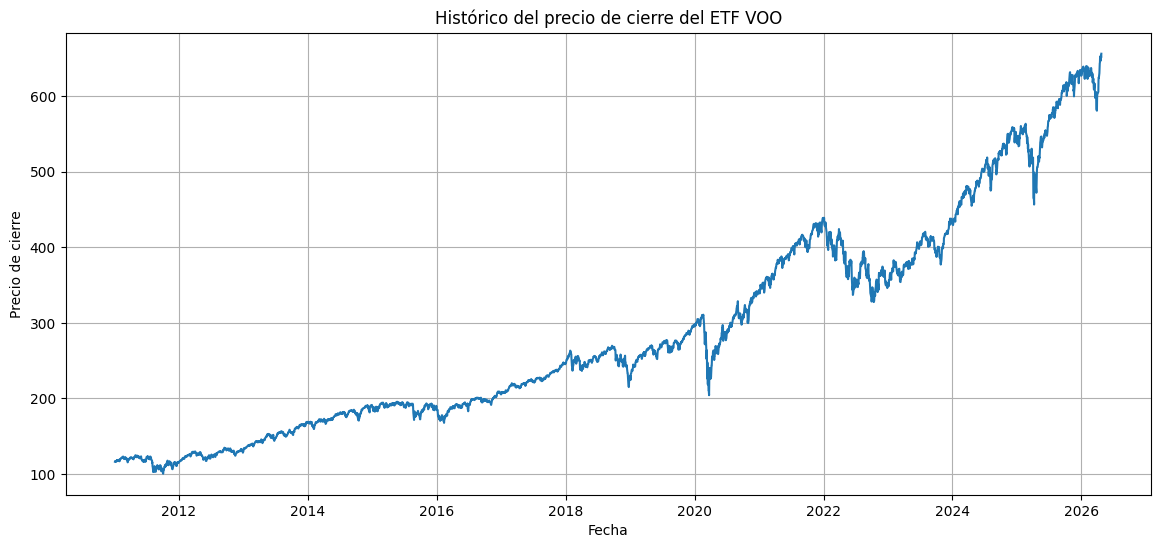

In [10]:
plt.figure(figsize=(14, 6))
plt.plot(datos_voo["fecha"], datos_voo["precio_cierre"])
plt.title("Histórico del precio de cierre del ETF VOO")
plt.xlabel("Fecha")
plt.ylabel("Precio de cierre")
plt.grid(True)
plt.show()

## 9. Distribución del cambio porcentual diario

Además del precio, se analiza la variable `cambio_porcentual`, que representa el retorno diario reportado en el dataset. Esta variable es importante porque permite observar la magnitud típica de los movimientos diarios del ETF.

En problemas financieros, los retornos suelen concentrarse cerca de cero, con algunos valores extremos asociados a periodos de alta volatilidad. Esta información será útil para construir variables derivadas y para definir una variable objetivo razonable para el modelo de clasificación.

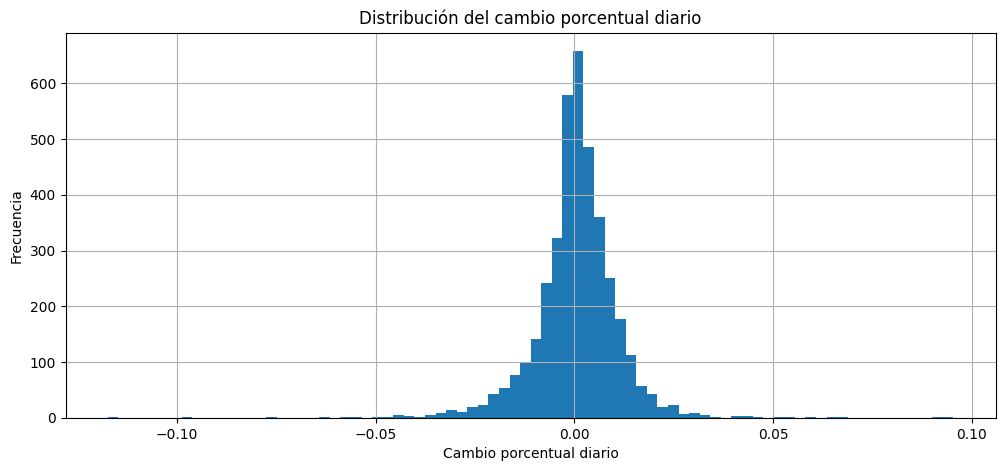

count    3879.000000
mean        0.000507
std         0.010772
min        -0.117400
25%        -0.003700
50%         0.000600
75%         0.005700
max         0.095400
Name: cambio_porcentual, dtype: float64

In [11]:
plt.figure(figsize=(12, 5))
plt.hist(datos_voo["cambio_porcentual"], bins=80)
plt.title("Distribución del cambio porcentual diario")
plt.xlabel("Cambio porcentual diario")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.show()

display(datos_voo["cambio_porcentual"].describe())

## 10. Comportamiento histórico del volumen transado

Se analiza el volumen transado para observar la actividad del ETF a lo largo del tiempo. Esta variable puede aportar información complementaria al precio, ya que aumentos fuertes en volumen pueden reflejar mayor participación del mercado o eventos relevantes.

Sin embargo, como se identificaron valores faltantes en esta columna, cualquier uso del volumen en el modelo debe realizarse después de aplicar una estrategia de tratamiento de datos nulos.

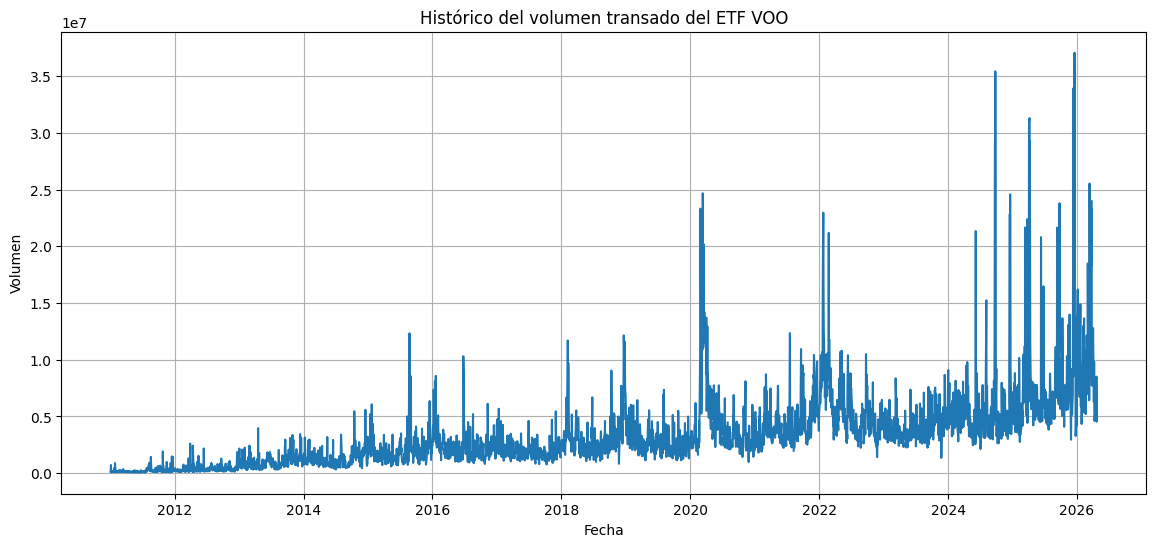

In [12]:
plt.figure(figsize=(14, 6))
plt.plot(datos_voo["fecha"], datos_voo["volumen"])
plt.title("Histórico del volumen transado del ETF VOO")
plt.xlabel("Fecha")
plt.ylabel("Volumen")
plt.grid(True)
plt.show()

## Interpretación del análisis exploratorio inicial

La exploración inicial muestra que el dataset contiene una serie histórica amplia del ETF VOO, desde enero de 2011 hasta abril de 2026. La gráfica del precio de cierre evidencia una tendencia creciente de largo plazo, aunque con periodos de caídas importantes y recuperación posterior. Esto confirma que el activo no tiene un comportamiento lineal simple y que el modelo no debería basarse únicamente en el nivel absoluto del precio.

También se observa que la distribución del cambio porcentual diario está altamente concentrada alrededor de cero. La mayoría de los movimientos diarios son pequeños, pero existen valores extremos negativos y positivos. En particular, el mínimo diario observado es aproximadamente -11,74% y el máximo diario aproximadamente 9,54%. Esto es consistente con el comportamiento típico de activos financieros, donde los retornos diarios suelen tener alta concentración cerca de cero y algunos eventos extremos en periodos de volatilidad.

La gráfica de volumen muestra que la actividad transada cambia considerablemente a lo largo del tiempo y presenta picos fuertes en algunos periodos. Esto sugiere que el volumen puede aportar información al modelo, pero no conviene usarlo únicamente como valor absoluto. Más adelante será preferible construir variables relativas como cambios porcentuales de volumen, promedios móviles o razones frente a su media reciente.

Además, se identificaron 29 registros con volumen nulo, equivalentes al 0,75% del dataset. Al revisar estos casos, se observa que en todos ellos los precios de apertura, cierre, máximo y mínimo son iguales, el cambio porcentual es cero y no existe volumen reportado. Esto sugiere que no corresponden a días normales de negociación, sino a registros sin actividad de mercado. Por esta razón, se eliminarán antes del modelado en lugar de imputar el volumen.

## 11. Tratamiento de registros sin operación

En esta sección se eliminan los registros que no parecen representar días reales de negociación. El criterio utilizado combina tres condiciones: volumen faltante, precios OHLC iguales y cambio porcentual igual a cero.

Esta decisión es metodológicamente más sólida que imputar el volumen, porque imputar implicaría crear artificialmente actividad de mercado en días donde no hubo negociación reportada. Para un modelo financiero, este tipo de registros puede introducir ruido y afectar la construcción de variables basadas en retornos, volatilidad o volumen.

In [13]:
registros_sin_operacion = (
    datos_voo["volumen"].isna()
    & (datos_voo["precio_cierre"] == datos_voo["precio_apertura"])
    & (datos_voo["precio_cierre"] == datos_voo["precio_maximo"])
    & (datos_voo["precio_cierre"] == datos_voo["precio_minimo"])
    & (datos_voo["cambio_porcentual"] == 0)
)

datos_sin_operacion = datos_voo.loc[registros_sin_operacion].copy()
datos_sin_operacion["dia_semana"] = datos_sin_operacion["fecha"].dt.day_name()

print(f"Registros con volumen nulo: {datos_voo['volumen'].isna().sum()}")
print(f"Registros identificados como sin operación: {registros_sin_operacion.sum()}")

display(datos_sin_operacion)

Registros con volumen nulo: 29
Registros identificados como sin operación: 29


,fecha,precio_cierre,precio_apertura,precio_maximo,precio_minimo,volumen,cambio_porcentual,dia_semana
2295,2020-02-17,310.28,310.28,310.28,310.28,NaN,0.0,Monday
2315,2020-03-14,247.64,247.64,247.64,247.64,NaN,0.0,Saturday
2321,2020-03-21,210.74,210.74,210.74,210.74,NaN,0.0,Saturday
2327,2020-03-28,232.86,232.86,232.86,232.86,NaN,0.0,Saturday
2352,2020-05-02,259.82,259.82,259.82,259.82,NaN,0.0,Saturday
2353,2020-05-03,259.82,259.82,259.82,259.82,NaN,0.0,Sunday
2378,2020-06-07,293.61,293.61,293.61,293.61,NaN,0.0,Sunday
2398,2020-07-04,286.81,286.81,286.81,286.81,NaN,0.0,Saturday
2399,2020-07-05,286.81,286.81,286.81,286.81,NaN,0.0,Sunday
2405,2020-07-11,291.80,291.80,291.80,291.80,NaN,0.0,Saturday


In [14]:
datos_voo = datos_voo.loc[~registros_sin_operacion].copy()
datos_voo = datos_voo.reset_index(drop=True)

print(f"Cantidad de registros después de eliminar días sin operación: {datos_voo.shape[0]}")
print(f"Cantidad de columnas: {datos_voo.shape[1]}")

print("\nValores nulos después del tratamiento:")
display(datos_voo.isna().sum())

display(datos_voo.head())
display(datos_voo.tail())

Cantidad de registros después de eliminar días sin operación: 3850
Cantidad de columnas: 7

Valores nulos después del tratamiento:


fecha                0
precio_cierre        0
precio_apertura      0
precio_maximo        0
precio_minimo        0
volumen              0
cambio_porcentual    0
dtype: int64

,fecha,precio_cierre,precio_apertura,precio_maximo,precio_minimo,volumen,cambio_porcentual
0,2011-01-03,116.22,115.94,116.66,115.90,119180.0,0.0094
1,2011-01-04,116.12,116.56,116.56,115.50,108330.0,-0.0009
2,2011-01-05,116.74,115.86,116.80,115.72,717740.0,0.0053
3,2011-01-06,116.54,116.84,116.92,116.22,72420.0,-0.0017
4,2011-01-07,116.31,116.70,116.86,115.48,82240.0,-0.0020


,fecha,precio_cierre,precio_apertura,precio_maximo,precio_minimo,volumen,cambio_porcentual
3845,2026-04-20,651.54,651.62,652.60,649.17,6380000.0,-0.0019
3846,2026-04-21,647.25,652.94,653.86,645.94,8510000.0,-0.0066
3847,2026-04-22,653.90,651.98,654.19,651.09,4540000.0,0.0103
3848,2026-04-23,651.26,652.23,654.90,645.66,6520000.0,-0.0040
3849,2026-04-24,656.42,653.40,656.82,651.82,4790000.0,0.0079


## Conclusión de la limpieza inicial

Después de eliminar los registros sin operación, el dataset queda sin valores nulos y conserva únicamente observaciones útiles para el análisis financiero. Esta versión limpia será la base para construir variables predictoras y definir la variable objetivo.

La limpieza realizada no modifica artificialmente los precios ni el volumen. En lugar de imputar valores, se eliminaron registros que no representaban actividad real de mercado, lo cual reduce el riesgo de introducir ruido en el entrenamiento de los modelos.

## 12. Definición de la variable objetivo

Para convertir el problema financiero en una tarea de aprendizaje supervisado, se define una variable objetivo binaria. El objetivo no es predecir exactamente el precio futuro del ETF, sino estimar si existe una oportunidad de inversión en un horizonte temporal determinado.

En este proyecto se entiende como oportunidad de inversión un escenario en el que el precio futuro del ETF supera el precio actual en una proporción mínima definida. Esta condición evita que el modelo clasifique como oportunidad cualquier aumento marginal de precio, lo cual sería poco útil para un usuario final.

Se evaluarán tres horizontes temporales:

- 4 días hábiles: representa una señal de muy corto plazo.
- 15 días hábiles: representa una señal de corto plazo.
- 20 días hábiles: aproxima un horizonte mensual de mercado.

Para cada horizonte se calcula el retorno futuro como:

\[
retorno\ futuro = \frac{precio\ futuro - precio\ actual}{precio\ actual}
\]

Luego, se asigna la clase positiva cuando el retorno futuro supera un umbral mínimo. Esta formulación permite entrenar modelos de clasificación binaria y posteriormente construir una capa de decisión interpretable para la aplicación.

In [15]:
def calcular_retorno_futuro(datos, horizonte_dias):
    """
    Calcula el retorno futuro del precio de cierre para un horizonte dado.

    El retorno futuro compara el precio de cierre actual con el precio de
    cierre observado después de una cantidad determinada de días hábiles.

    Args:
        datos: DataFrame que contiene la columna `precio_cierre`.
        horizonte_dias: Número de días hacia adelante usados para calcular
            el retorno futuro.

    Returns:
        Serie de pandas con el retorno futuro para cada observación.
        Las últimas observaciones quedan como `NaN`, porque no existe
        información futura suficiente para calcular el retorno.
    """
    precio_futuro = datos["precio_cierre"].shift(-horizonte_dias)
    retorno_futuro = (precio_futuro - datos["precio_cierre"]) / datos["precio_cierre"]

    return retorno_futuro


def crear_variable_objetivo(datos, horizonte_dias, umbral_retorno):
    """
    Crea una variable objetivo binaria para detectar oportunidades de inversión.

    La clase positiva se asigna cuando el retorno futuro del ETF es mayor o
    igual al umbral definido para el horizonte temporal analizado.

    Args:
        datos: DataFrame limpio con la columna `precio_cierre`.
        horizonte_dias: Número de días hábiles hacia adelante.
        umbral_retorno: Retorno mínimo requerido para considerar que existe
            una oportunidad de inversión.

    Returns:
        DataFrame con dos nuevas columnas:
        `retorno_futuro_{horizonte_dias}d` y
        `objetivo_oportunidad_{horizonte_dias}d`.
    """
    datos_con_objetivo = datos.copy()

    columna_retorno = f"retorno_futuro_{horizonte_dias}d"
    columna_objetivo = f"objetivo_oportunidad_{horizonte_dias}d"

    datos_con_objetivo[columna_retorno] = calcular_retorno_futuro(
        datos=datos_con_objetivo,
        horizonte_dias=horizonte_dias,
    )

    datos_con_objetivo[columna_objetivo] = np.where(
        datos_con_objetivo[columna_retorno] >= umbral_retorno,
        1,
        0,
    )

    datos_con_objetivo.loc[
        datos_con_objetivo[columna_retorno].isna(),
        columna_objetivo,
    ] = np.nan

    return datos_con_objetivo

## 13. Construcción de objetivos por horizonte

Se crean variables objetivo para tres horizontes temporales. Los umbrales no son iguales para todos los horizontes, porque no es razonable exigir el mismo retorno mínimo en 4 días que en 20 días.

Para el horizonte de 4 días se utiliza un umbral menor, mientras que para horizontes más largos se exige un retorno mayor. Esta decisión busca que la clase positiva represente una oportunidad relevante y no simplemente cualquier variación mínima del precio.

In [16]:
configuracion_objetivos = {
    4: 0.005,
    15: 0.015,
    20: 0.020,
}

datos_modelado = datos_voo.copy()

for horizonte_dias, umbral_retorno in configuracion_objetivos.items():
    datos_modelado = crear_variable_objetivo(
        datos=datos_modelado,
        horizonte_dias=horizonte_dias,
        umbral_retorno=umbral_retorno,
    )

columnas_objetivo = [
    columna
    for columna in datos_modelado.columns
    if columna.startswith("objetivo_oportunidad")
]

columnas_retorno_futuro = [
    columna
    for columna in datos_modelado.columns
    if columna.startswith("retorno_futuro")
]

display(datos_modelado[
    ["fecha", "precio_cierre"] + columnas_retorno_futuro + columnas_objetivo
].head())

display(datos_modelado[
    ["fecha", "precio_cierre"] + columnas_retorno_futuro + columnas_objetivo
].tail(25))

,fecha,precio_cierre,retorno_futuro_4d,retorno_futuro_15d,retorno_futuro_20d,objetivo_oportunidad_4d,objetivo_oportunidad_15d,objetivo_oportunidad_20d
0,2011-01-03,116.22,0.000774,0.016348,0.028567,0.0,1.0,1.0
1,2011-01-04,116.12,0.000689,0.022563,0.027730,0.0,1.0,1.0
2,2011-01-05,116.74,-0.001371,0.018503,0.024842,0.0,1.0,1.0
3,2011-01-06,116.54,0.009267,0.002231,0.029346,1.0,0.0,1.0
4,2011-01-07,116.31,0.009887,0.011951,0.037916,1.0,0.0,1.0


,fecha,precio_cierre,retorno_futuro_4d,retorno_futuro_15d,retorno_futuro_20d,objetivo_oportunidad_4d,objetivo_oportunidad_15d,objetivo_oportunidad_20d
3825,2026-03-20,597.94,-0.005051,0.054822,0.089641,0.0,1.0,1.0
3826,2026-03-23,604.43,-0.035521,0.056119,0.070844,0.0,1.0,1.0
3827,2026-03-24,602.38,-0.035609,0.068180,0.085527,0.0,1.0,1.0
3828,2026-03-25,605.66,-0.013390,0.064723,0.075290,0.0,1.0,1.0
3829,2026-03-26,594.92,0.012405,0.097257,0.103375,1.0,1.0,1.0
3830,2026-03-27,582.96,0.034359,0.117641,NaN,1.0,1.0,NaN
3831,2026-03-30,580.93,0.042587,0.114162,NaN,1.0,1.0,NaN
3832,2026-03-31,597.55,0.014208,0.094302,NaN,1.0,1.0,NaN
3833,2026-04-01,602.30,0.031612,0.081288,NaN,1.0,1.0,NaN
3834,2026-04-02,602.99,0.036535,0.088608,NaN,1.0,1.0,NaN


## 14. Revisión del balance de clases

Después de construir las variables objetivo, se revisa la proporción de clases para cada horizonte. Este paso es importante porque un dataset muy desbalanceado puede producir modelos aparentemente buenos, pero poco útiles.

Por ejemplo, si la mayoría de observaciones pertenecen a la clase positiva, un modelo que siempre prediga oportunidad podría obtener una exactitud alta sin realmente aprender patrones relevantes. Por esta razón se revisan tanto los conteos como los porcentajes de cada clase.

In [17]:
resumen_balance_clases = []

for horizonte_dias in configuracion_objetivos:
    columna_objetivo = f"objetivo_oportunidad_{horizonte_dias}d"
    datos_validos_objetivo = datos_modelado.dropna(subset=[columna_objetivo]).copy()

    conteos_clase = datos_validos_objetivo[columna_objetivo].value_counts().sort_index()
    porcentajes_clase = datos_validos_objetivo[columna_objetivo].value_counts(normalize=True).sort_index()

    resumen_balance_clases.append({
        "horizonte_dias": horizonte_dias,
        "umbral_retorno": configuracion_objetivos[horizonte_dias],
        "total_observaciones": datos_validos_objetivo.shape[0],
        "clase_0_conteo": int(conteos_clase.get(0.0, 0)),
        "clase_1_conteo": int(conteos_clase.get(1.0, 0)),
        "clase_0_porcentaje": porcentajes_clase.get(0.0, 0),
        "clase_1_porcentaje": porcentajes_clase.get(1.0, 0),
    })

balance_clases = pd.DataFrame(resumen_balance_clases)

display(balance_clases)

,horizonte_dias,umbral_retorno,total_observaciones,clase_0_conteo,clase_1_conteo,clase_0_porcentaje,clase_1_porcentaje
0,4,0.005,3846,2096,1750,0.544982,0.455018
1,15,0.015,3835,2105,1730,0.548892,0.451108
2,20,0.020,3830,2193,1637,0.572585,0.427415


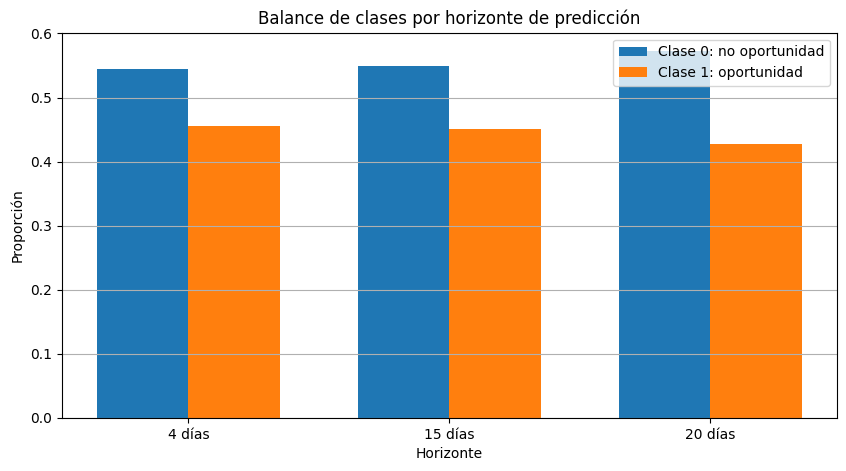

In [18]:
plt.figure(figsize=(10, 5))

posiciones_horizonte = np.arange(len(balance_clases))
ancho_barra = 0.35

plt.bar(
    posiciones_horizonte - ancho_barra / 2,
    balance_clases["clase_0_porcentaje"],
    width=ancho_barra,
    label="Clase 0: no oportunidad",
)

plt.bar(
    posiciones_horizonte + ancho_barra / 2,
    balance_clases["clase_1_porcentaje"],
    width=ancho_barra,
    label="Clase 1: oportunidad",
)

plt.xticks(
    posiciones_horizonte,
    balance_clases["horizonte_dias"].astype(str) + " días",
)

plt.title("Balance de clases por horizonte de predicción")
plt.xlabel("Horizonte")
plt.ylabel("Proporción")
plt.legend()
plt.grid(True, axis="y")
plt.show()

## Interpretación del balance de clases

La revisión del balance de clases muestra que los tres horizontes definidos generan una distribución relativamente equilibrada entre la clase positiva y la clase negativa.

Para el horizonte de 4 días, la clase positiva representa aproximadamente el 45,5% de las observaciones. Para 15 días, representa aproximadamente el 45,1%, y para 20 días representa aproximadamente el 42,7%. Esto indica que los umbrales definidos no producen un problema extremadamente desbalanceado.

Esta observación es importante porque evita que el modelo pueda obtener buenos resultados simplemente prediciendo siempre la clase mayoritaria. Sin embargo, esta revisión todavía es global. En etapas posteriores será necesario revisar el balance de clases en los conjuntos de entrenamiento, validación y prueba, respetando el orden temporal de los datos.

Con base en estos resultados, se mantienen los tres horizontes propuestos:

- 4 días con umbral de retorno mínimo de 0,5%.
- 15 días con umbral de retorno mínimo de 1,5%.
- 20 días con umbral de retorno mínimo de 2,0%.

Estos horizontes permitirán que la aplicación final genere una recomendación más rica que una simple respuesta de comprar o no comprar, ya que podrá diferenciar entre señales de muy corto plazo, corto plazo y horizonte mensual.

## 15. Ingeniería de características

Los modelos de aprendizaje de máquina no se entrenarán únicamente con las variables originales del dataset. Aunque las columnas de precio y volumen contienen información relevante, utilizar solo sus valores absolutos puede ser insuficiente para capturar el comportamiento financiero del ETF.

Por esta razón, se construyen variables derivadas que resumen el comportamiento reciente del activo. Estas variables buscan representar conceptos como retorno, volatilidad, momentum, distancia frente a máximos o mínimos recientes y cambios en volumen.

Todas las variables predictoras se construyen utilizando únicamente información disponible hasta la fecha actual de cada observación. Esto es fundamental para evitar fuga de información, es decir, evitar que el modelo aprenda usando datos del futuro.

In [19]:
def agregar_variables_de_retorno(datos):
    """
    Agrega variables basadas en retornos históricos del precio.

    Estas variables describen cambios porcentuales recientes del precio de
    cierre. Se utilizan retornos simples y retornos logarítmicos porque son
    más informativos que el precio absoluto cuando se trabaja con series
    financieras.

    Args:
        datos: DataFrame con la columna `precio_cierre`.

    Returns:
        DataFrame con nuevas columnas de retornos históricos.
    """
    datos_features = datos.copy()

    datos_features["retorno_diario"] = datos_features["precio_cierre"].pct_change()
    datos_features["retorno_logaritmico"] = np.log(
        datos_features["precio_cierre"] / datos_features["precio_cierre"].shift(1)
    )

    datos_features["retorno_3d"] = datos_features["precio_cierre"].pct_change(3)
    datos_features["retorno_5d"] = datos_features["precio_cierre"].pct_change(5)
    datos_features["retorno_10d"] = datos_features["precio_cierre"].pct_change(10)
    datos_features["retorno_20d"] = datos_features["precio_cierre"].pct_change(20)

    return datos_features


def agregar_variables_de_rango(datos):
    """
    Agrega variables relacionadas con el rango diario de negociación.

    Estas variables describen la diferencia entre precio máximo, mínimo,
    apertura y cierre. Son útiles para aproximar volatilidad diaria y presión
    compradora o vendedora dentro de cada jornada.

    Args:
        datos: DataFrame con columnas de precios OHLC.

    Returns:
        DataFrame con variables derivadas del rango diario.
    """
    datos_features = datos.copy()

    datos_features["rango_diario"] = (
        datos_features["precio_maximo"] - datos_features["precio_minimo"]
    ) / datos_features["precio_cierre"]

    datos_features["cambio_apertura_cierre"] = (
        datos_features["precio_cierre"] - datos_features["precio_apertura"]
    ) / datos_features["precio_apertura"]

    datos_features["posicion_cierre_rango"] = (
        datos_features["precio_cierre"] - datos_features["precio_minimo"]
    ) / (
        datos_features["precio_maximo"] - datos_features["precio_minimo"]
    )

    datos_features["posicion_cierre_rango"] = datos_features[
        "posicion_cierre_rango"
    ].replace([np.inf, -np.inf], np.nan)

    return datos_features


def agregar_medias_moviles(datos, ventanas):
    """
    Agrega medias móviles y distancia del precio frente a esas medias.

    Las medias móviles resumen la tendencia reciente del precio. La distancia
    entre el precio actual y su media móvil permite identificar si el activo
    está relativamente extendido o rezagado frente a su comportamiento reciente.

    Args:
        datos: DataFrame con la columna `precio_cierre`.
        ventanas: Lista de ventanas temporales para calcular medias móviles.

    Returns:
        DataFrame con medias móviles y distancias relativas.
    """
    datos_features = datos.copy()

    for ventana in ventanas:
        columna_media = f"media_movil_{ventana}d"
        columna_distancia = f"distancia_media_movil_{ventana}d"

        datos_features[columna_media] = (
            datos_features["precio_cierre"]
            .rolling(window=ventana)
            .mean()
        )

        datos_features[columna_distancia] = (
            datos_features["precio_cierre"] - datos_features[columna_media]
        ) / datos_features[columna_media]

    return datos_features


def agregar_variables_de_volatilidad(datos, ventanas):
    """
    Agrega variables de volatilidad histórica.

    La volatilidad se calcula como la desviación estándar de los retornos
    diarios en diferentes ventanas temporales. Esta información permite
    representar periodos de mayor o menor incertidumbre en el mercado.

    Args:
        datos: DataFrame con la columna `retorno_diario`.
        ventanas: Lista de ventanas temporales para calcular volatilidad.

    Returns:
        DataFrame con variables de volatilidad histórica.
    """
    datos_features = datos.copy()

    for ventana in ventanas:
        datos_features[f"volatilidad_{ventana}d"] = (
            datos_features["retorno_diario"]
            .rolling(window=ventana)
            .std()
        )

    return datos_features


def agregar_variables_de_momentum(datos, ventanas):
    """
    Agrega variables de momentum del precio.

    El momentum mide el cambio acumulado del precio en ventanas recientes.
    Puede ayudar a identificar si el ETF viene en una tendencia positiva o
    negativa antes de la fecha evaluada.

    Args:
        datos: DataFrame con la columna `precio_cierre`.
        ventanas: Lista de horizontes pasados para calcular momentum.

    Returns:
        DataFrame con variables de momentum.
    """
    datos_features = datos.copy()

    for ventana in ventanas:
        datos_features[f"momentum_{ventana}d"] = (
            datos_features["precio_cierre"] / datos_features["precio_cierre"].shift(ventana)
        ) - 1

    return datos_features


def agregar_distancia_a_extremos(datos, ventanas):
    """
    Agrega variables de distancia frente a máximos y mínimos recientes.

    Estas variables permiten medir si el precio actual está cerca de un máximo
    reciente o de un mínimo reciente. Esto es relevante para el proyecto porque
    la aplicación busca apoyar la identificación de posibles momentos de entrada.

    Args:
        datos: DataFrame con la columna `precio_cierre`.
        ventanas: Lista de ventanas temporales para calcular máximos y mínimos.

    Returns:
        DataFrame con distancias relativas a máximos y mínimos recientes.
    """
    datos_features = datos.copy()

    for ventana in ventanas:
        maximo_reciente = datos_features["precio_cierre"].rolling(window=ventana).max()
        minimo_reciente = datos_features["precio_cierre"].rolling(window=ventana).min()

        datos_features[f"distancia_maximo_{ventana}d"] = (
            datos_features["precio_cierre"] - maximo_reciente
        ) / maximo_reciente

        datos_features[f"distancia_minimo_{ventana}d"] = (
            datos_features["precio_cierre"] - minimo_reciente
        ) / minimo_reciente

    return datos_features


def agregar_variables_de_volumen(datos, ventanas):
    """
    Agrega variables derivadas del volumen transado.

    El volumen puede reflejar cambios en la actividad del mercado. En lugar de
    usar únicamente el volumen absoluto, se crean variables relativas frente a
    su comportamiento reciente.

    Args:
        datos: DataFrame con la columna `volumen`.
        ventanas: Lista de ventanas temporales para calcular medias de volumen.

    Returns:
        DataFrame con variables derivadas del volumen.
    """
    datos_features = datos.copy()

    datos_features["cambio_volumen"] = datos_features["volumen"].pct_change()
    datos_features["cambio_volumen"] = datos_features["cambio_volumen"].replace(
        [np.inf, -np.inf],
        np.nan,
    )

    for ventana in ventanas:
        columna_media_volumen = f"media_volumen_{ventana}d"
        columna_ratio_volumen = f"ratio_volumen_{ventana}d"

        datos_features[columna_media_volumen] = (
            datos_features["volumen"]
            .rolling(window=ventana)
            .mean()
        )

        datos_features[columna_ratio_volumen] = (
            datos_features["volumen"] / datos_features[columna_media_volumen]
        )

    return datos_features


def construir_variables_predictoras(datos):
    """
    Construye el conjunto completo de variables predictoras.

    Esta función aplica de forma ordenada las transformaciones necesarias para
    enriquecer el dataset con variables financieras derivadas. Todas las
    variables se construyen usando información histórica o contemporánea
    disponible para cada fecha.

    Args:
        datos: DataFrame limpio con precios, volumen y variables objetivo.

    Returns:
        DataFrame enriquecido con variables predictoras para modelado.
    """
    ventanas_cortas = [5, 10, 20]
    ventanas_largas = [20, 50, 100]

    datos_features = datos.copy()

    datos_features = agregar_variables_de_retorno(datos_features)
    datos_features = agregar_variables_de_rango(datos_features)
    datos_features = agregar_medias_moviles(datos_features, ventanas_largas)
    datos_features = agregar_variables_de_volatilidad(datos_features, ventanas_cortas)
    datos_features = agregar_variables_de_momentum(datos_features, ventanas_cortas)
    datos_features = agregar_distancia_a_extremos(datos_features, ventanas_largas)
    datos_features = agregar_variables_de_volumen(datos_features, ventanas_cortas)

    return datos_features

## 16. Construcción del dataset enriquecido

A continuación se aplican las funciones de ingeniería de características al dataset limpio. El resultado es un dataset enriquecido que contiene tanto las variables originales como las variables derivadas necesarias para el entrenamiento de los modelos.

En esta etapa todavía no se eliminan automáticamente todas las filas con valores faltantes. Primero se revisa cuántos valores nulos aparecen como consecuencia natural de usar diferencias, retornos y ventanas móviles.

In [20]:
datos_features = construir_variables_predictoras(datos_modelado)

print(f"Filas del dataset con features: {datos_features.shape[0]}")
print(f"Columnas del dataset con features: {datos_features.shape[1]}")

display(datos_features.head())
display(datos_features.tail())

Filas del dataset con features: 3850
Columnas del dataset con features: 47


,fecha,precio_cierre,precio_apertura,precio_maximo,precio_minimo,volumen,cambio_porcentual,retorno_futuro_4d,objetivo_oportunidad_4d,retorno_futuro_15d,objetivo_oportunidad_15d,retorno_futuro_20d,objetivo_oportunidad_20d,retorno_diario,retorno_logaritmico,retorno_3d,retorno_5d,retorno_10d,retorno_20d,rango_diario,cambio_apertura_cierre,posicion_cierre_rango,media_movil_20d,distancia_media_movil_20d,media_movil_50d,distancia_media_movil_50d,media_movil_100d,distancia_media_movil_100d,volatilidad_5d,volatilidad_10d,volatilidad_20d,momentum_5d,momentum_10d,momentum_20d,distancia_maximo_20d,distancia_minimo_20d,distancia_maximo_50d,distancia_minimo_50d,distancia_maximo_100d,distancia_minimo_100d,cambio_volumen,media_volumen_5d,ratio_volumen_5d,media_volumen_10d,ratio_volumen_10d,media_volumen_20d,ratio_volumen_20d
0,2011-01-03,116.22,115.94,116.66,115.90,119180.0,0.0094,0.000774,0.0,0.016348,1.0,0.028567,1.0,NaN,NaN,NaN,NaN,NaN,NaN,0.006539,0.002415,0.421053,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2011-01-04,116.12,116.56,116.56,115.50,108330.0,-0.0009,0.000689,0.0,0.022563,1.0,0.027730,1.0,-0.000860,-0.000861,NaN,NaN,NaN,NaN,0.009128,-0.003775,0.584906,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.091039,NaN,NaN,NaN,NaN,NaN,NaN
2,2011-01-05,116.74,115.86,116.80,115.72,717740.0,0.0053,-0.001371,0.0,0.018503,1.0,0.024842,1.0,0.005339,0.005325,NaN,NaN,NaN,NaN,0.009251,0.007595,0.944444,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.625496,NaN,NaN,NaN,NaN,NaN,NaN
3,2011-01-06,116.54,116.84,116.92,116.22,72420.0,-0.0017,0.009267,1.0,0.002231,0.0,0.029346,1.0,-0.001713,-0.001715,0.002753,NaN,NaN,NaN,0.006007,-0.002568,0.457143,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.899100,NaN,NaN,NaN,NaN,NaN,NaN
4,2011-01-07,116.31,116.70,116.86,115.48,82240.0,-0.0020,0.009887,1.0,0.011951,0.0,0.037916,1.0,-0.001974,-0.001976,0.001636,NaN,NaN,NaN,0.011865,-0.003342,0.601449,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.135598,219982.0,0.373849,NaN,NaN,NaN,NaN


,fecha,precio_cierre,precio_apertura,precio_maximo,precio_minimo,volumen,cambio_porcentual,retorno_futuro_4d,objetivo_oportunidad_4d,retorno_futuro_15d,objetivo_oportunidad_15d,retorno_futuro_20d,objetivo_oportunidad_20d,retorno_diario,retorno_logaritmico,retorno_3d,retorno_5d,retorno_10d,retorno_20d,rango_diario,cambio_apertura_cierre,posicion_cierre_rango,media_movil_20d,distancia_media_movil_20d,media_movil_50d,distancia_media_movil_50d,media_movil_100d,distancia_media_movil_100d,volatilidad_5d,volatilidad_10d,volatilidad_20d,momentum_5d,momentum_10d,momentum_20d,distancia_maximo_20d,distancia_minimo_20d,distancia_maximo_50d,distancia_minimo_50d,distancia_maximo_100d,distancia_minimo_100d,cambio_volumen,media_volumen_5d,ratio_volumen_5d,media_volumen_10d,ratio_volumen_10d,media_volumen_20d,ratio_volumen_20d
3845,2026-04-20,651.54,651.62,652.60,649.17,6380000.0,-0.0019,0.00749,1.0,NaN,NaN,NaN,NaN,-0.001900,-0.001901,0.012573,0.033010,0.075734,0.089641,0.005264,-0.000123,0.690962,615.9245,0.057824,621.4178,0.048473,626.1860,0.040490,0.006247,0.008148,0.011585,0.033010,0.075734,0.089641,-0.001900,0.121546,-0.001900,0.121546,-0.001900,0.121546,-0.184143,6058000.0,1.053153,6206000.0,1.028037,10093000.0,0.632121
3846,2026-04-21,647.25,652.94,653.86,645.94,8510000.0,-0.0066,NaN,NaN,NaN,NaN,NaN,NaN,-0.006584,-0.006606,0.003706,0.013942,0.067999,0.070844,0.012236,-0.008714,0.165404,618.0655,0.047219,621.6580,0.041167,626.5091,0.033106,0.007539,0.009075,0.011726,0.013942,0.067999,0.070844,-0.008471,0.114162,-0.008471,0.114162,-0.008471,0.114162,0.333856,6752000.0,1.260367,6388000.0,1.332185,9318000.0,0.913286
3847,2026-04-22,653.90,651.98,654.19,651.09,4540000.0,0.0103,NaN,NaN,NaN,NaN,NaN,NaN,0.010274,0.010222,0.001716,0.016241,0.052403,0.085527,0.004741,0.002945,0.906452,620.6415,0.053587,621.9714,0.051335,626.8415,0.043166,0.007989,0.006546,0.011702,0.016241,0.052403,0.085527,0.000000,0.125609,0.000000,0.125609,0.000000,0.125609,-0.466510,6626000.0,0.685180,5861000.0,0.774612,8627000.0,0.526255
3848,2026-04-23,651.26,652.23,654.90,645.66,6520000.0,-0.0040,NaN,NaN,NaN,NaN,NaN,NaN,-0.004037,-0.004045,-0.000430,0.009925,0.041983,0.075290,0.014188,-0.001487,0.606061,622.9215,0.045493,622.2678,0.046591,627.1046,0.038519,0.008653,0.007144,0.011839,0.009925,0.041983,0.075290,-0.004037,0.121065,-0.004037,0.121065,-0.004037,0.121065,0.436123,6754000.0,0.965354,5963000.0,1.093409,7788500.0,0.837132
3849,2026-04-24,656.42,653.40,656.82,651.82,4790000.0,0.0079,NaN,NaN,NaN,NaN,NaN,NaN,0.007923,0.007892,0.014168,0.005576,0.050945,0.103375,0.007617,0.004622,0.920000,625.9965,0.048600,622.6692,0.054203,627.3847,0.046280,0.007503,0.007016,0.010733,0.005576,0.050945,0.103375,0.000000,0.129947,0.000000,0.129947,0.000000,0.129947,-0.265337,6148000.0,0.779115,5981000.0,0.800869,7642500.0,0.626758


## 17. Revisión de valores faltantes generados por ingeniería de características

Las variables basadas en rezagos y ventanas móviles generan valores faltantes al inicio de la serie. Esto ocurre porque para calcular, por ejemplo, una media móvil de 100 días, se necesitan al menos 100 observaciones históricas previas.

Estos valores faltantes no representan errores del dataset, sino una consecuencia esperada de la construcción de variables temporales. Antes del entrenamiento se eliminarán las filas que no tengan información suficiente para calcular todas las variables predictoras requeridas.

In [21]:
resumen_nulos_features = (
    datos_features
    .isna()
    .sum()
    .reset_index()
)

resumen_nulos_features.columns = ["columna", "cantidad_nulos"]
resumen_nulos_features = resumen_nulos_features[
    resumen_nulos_features["cantidad_nulos"] > 0
].sort_values("cantidad_nulos", ascending=False)

display(resumen_nulos_features)

,columna,cantidad_nulos
27,distancia_media_movil_100d,99
38,distancia_maximo_100d,99
39,distancia_minimo_100d,99
26,media_movil_100d,99
36,distancia_maximo_50d,49
24,media_movil_50d,49
37,distancia_minimo_50d,49
25,distancia_media_movil_50d,49
12,objetivo_oportunidad_20d,20
11,retorno_futuro_20d,20


## Interpretación de las variables construidas

Después de aplicar la ingeniería de características, el dataset pasa a tener 47 columnas. Las nuevas variables resumen información histórica del ETF relacionada con retornos recientes, volatilidad, momentum, distancia frente a medias móviles, distancia frente a máximos y mínimos recientes, y comportamiento relativo del volumen.

Los valores faltantes generados en esta etapa son esperados. Las variables calculadas con ventanas móviles necesitan una cantidad mínima de observaciones previas. Por ejemplo, una media móvil de 100 días solo puede calcularse a partir de la observación número 100. De forma similar, los retornos futuros y las variables objetivo generan valores faltantes al final del dataset porque no existen datos posteriores suficientes para calcularlos.

Para evitar fuga de información, las columnas de retorno futuro y las columnas objetivo no se utilizarán como variables predictoras. Estas columnas solo se emplean para definir la etiqueta supervisada de cada horizonte.

## 18. Selección de variables predictoras

En esta sección se define el conjunto de variables que serán usadas como entrada de los modelos. Se excluyen explícitamente las variables que representan información futura, como los retornos futuros y las variables objetivo.

También se evita usar la fecha como variable predictora, ya que puede inducir al modelo a aprender patrones asociados al paso del tiempo en lugar de relaciones financieras generalizables.

Adicionalmente, no se usarán directamente los precios absolutos ni el volumen absoluto como variables principales del modelo. En su lugar, se priorizan variables relativas como retornos, distancias porcentuales, volatilidades, momentum y ratios de volumen. Esto hace que el modelo dependa menos del nivel histórico del precio y más del comportamiento reciente del activo.

In [22]:
columnas_predictoras = [
    "cambio_porcentual",
    "retorno_diario",
    "retorno_logaritmico",
    "retorno_3d",
    "retorno_5d",
    "retorno_10d",
    "retorno_20d",
    "rango_diario",
    "cambio_apertura_cierre",
    "posicion_cierre_rango",
    "distancia_media_movil_20d",
    "distancia_media_movil_50d",
    "distancia_media_movil_100d",
    "volatilidad_5d",
    "volatilidad_10d",
    "volatilidad_20d",
    "momentum_5d",
    "momentum_10d",
    "momentum_20d",
    "distancia_maximo_20d",
    "distancia_minimo_20d",
    "distancia_maximo_50d",
    "distancia_minimo_50d",
    "distancia_maximo_100d",
    "distancia_minimo_100d",
    "cambio_volumen",
    "ratio_volumen_5d",
    "ratio_volumen_10d",
    "ratio_volumen_20d",
]

print(f"Cantidad de variables predictoras seleccionadas: {len(columnas_predictoras)}")

columnas_no_encontradas = [
    columna for columna in columnas_predictoras
    if columna not in datos_features.columns
]

print("Columnas no encontradas:")
print(columnas_no_encontradas)

Cantidad de variables predictoras seleccionadas: 29
Columnas no encontradas:
[]


## 19. Preparación del dataset de modelado por horizonte

Como se construyeron tres variables objetivo diferentes, se preparará un dataset de modelado independiente para cada horizonte. Esto permite entrenar y evaluar modelos específicos para 4, 15 y 20 días.

Para cada horizonte se eliminan únicamente las filas que tienen valores faltantes en las variables predictoras o en la variable objetivo correspondiente. No se eliminan filas por valores faltantes de objetivos de otros horizontes, ya que esos objetivos no son necesarios para entrenar el modelo del horizonte actual.

Esta decisión evita perder observaciones innecesariamente y mantiene la preparación metodológicamente alineada con cada problema de clasificación.

In [23]:
def preparar_dataset_por_horizonte(datos, columnas_entrada, horizonte_dias):
    """
    Prepara el dataset de modelado para un horizonte específico.

    Esta función selecciona las variables predictoras y la variable objetivo
    asociada al horizonte indicado. Luego elimina filas con valores faltantes
    únicamente en las columnas necesarias para ese modelo.

    Args:
        datos: DataFrame con variables predictoras y objetivos.
        columnas_entrada: Lista de columnas que serán usadas como variables
            predictoras.
        horizonte_dias: Horizonte temporal del objetivo, expresado en días
            hábiles.

    Returns:
        DataFrame limpio para modelado, con la columna `fecha`, las variables
        predictoras y la variable objetivo correspondiente.
    """
    columna_objetivo = f"objetivo_oportunidad_{horizonte_dias}d"

    columnas_modelo = ["fecha"] + columnas_entrada + [columna_objetivo]

    datos_horizonte = datos[columnas_modelo].copy()
    datos_horizonte = datos_horizonte.dropna().reset_index(drop=True)

    datos_horizonte[columna_objetivo] = datos_horizonte[columna_objetivo].astype(int)

    return datos_horizonte

In [24]:
datasets_por_horizonte = {}

for horizonte_dias in configuracion_objetivos:
    datasets_por_horizonte[horizonte_dias] = preparar_dataset_por_horizonte(
        datos=datos_features,
        columnas_entrada=columnas_predictoras,
        horizonte_dias=horizonte_dias,
    )

    print(f"Horizonte {horizonte_dias} días")
    print(f"Filas disponibles: {datasets_por_horizonte[horizonte_dias].shape[0]}")
    print(f"Columnas disponibles: {datasets_por_horizonte[horizonte_dias].shape[1]}")
    print("-" * 40)

Horizonte 4 días
Filas disponibles: 3747
Columnas disponibles: 31
----------------------------------------
Horizonte 15 días
Filas disponibles: 3736
Columnas disponibles: 31
----------------------------------------
Horizonte 20 días
Filas disponibles: 3731
Columnas disponibles: 31
----------------------------------------


## 20. División temporal en entrenamiento, validación y prueba

Debido a que el dataset corresponde a una serie temporal financiera, no se debe usar una división aleatoria de los datos. Una división aleatoria mezclaría observaciones antiguas y recientes, permitiendo que el modelo aprenda indirectamente información del futuro.

Por esta razón, se utiliza una división cronológica:

- 70% inicial para entrenamiento.
- 15% siguiente para validación.
- 15% final para prueba.

El conjunto de entrenamiento se usa para ajustar los modelos, el conjunto de validación para comparar configuraciones e hiperparámetros, y el conjunto de prueba para evaluar el desempeño final sobre datos más recientes no utilizados durante la selección del modelo.

In [25]:
def dividir_dataset_temporal(datos, columna_objetivo, proporcion_entrenamiento=0.70, proporcion_validacion=0.15):
    """
    Divide un dataset en entrenamiento, validación y prueba respetando el orden temporal.

    Esta función evita mezclar observaciones futuras con pasadas. La división se
    realiza de forma cronológica, usando las primeras observaciones para
    entrenamiento, las siguientes para validación y las últimas para prueba.

    Args:
        datos: DataFrame limpio para modelado.
        columna_objetivo: Nombre de la columna objetivo.
        proporcion_entrenamiento: Proporción inicial del dataset usada para
            entrenamiento.
        proporcion_validacion: Proporción siguiente usada para validación.

    Returns:
        Diccionario con los conjuntos `x_entrenamiento`, `y_entrenamiento`,
        `x_validacion`, `y_validacion`, `x_prueba`, `y_prueba`, junto con las
        fechas correspondientes de cada partición.
    """
    total_registros = datos.shape[0]

    indice_fin_entrenamiento = int(total_registros * proporcion_entrenamiento)
    indice_fin_validacion = int(total_registros * (proporcion_entrenamiento + proporcion_validacion))

    datos_entrenamiento = datos.iloc[:indice_fin_entrenamiento].copy()
    datos_validacion = datos.iloc[indice_fin_entrenamiento:indice_fin_validacion].copy()
    datos_prueba = datos.iloc[indice_fin_validacion:].copy()

    x_entrenamiento = datos_entrenamiento[columnas_predictoras]
    y_entrenamiento = datos_entrenamiento[columna_objetivo]

    x_validacion = datos_validacion[columnas_predictoras]
    y_validacion = datos_validacion[columna_objetivo]

    x_prueba = datos_prueba[columnas_predictoras]
    y_prueba = datos_prueba[columna_objetivo]

    return {
        "datos_entrenamiento": datos_entrenamiento,
        "datos_validacion": datos_validacion,
        "datos_prueba": datos_prueba,
        "x_entrenamiento": x_entrenamiento,
        "y_entrenamiento": y_entrenamiento,
        "x_validacion": x_validacion,
        "y_validacion": y_validacion,
        "x_prueba": x_prueba,
        "y_prueba": y_prueba,
    }

In [26]:
particiones_por_horizonte = {}

for horizonte_dias, datos_horizonte in datasets_por_horizonte.items():
    columna_objetivo = f"objetivo_oportunidad_{horizonte_dias}d"

    particiones_por_horizonte[horizonte_dias] = dividir_dataset_temporal(
        datos=datos_horizonte,
        columna_objetivo=columna_objetivo,
    )

## 21. Revisión de las particiones temporales

Después de dividir los datos, se revisan los rangos de fechas y el balance de clases en cada partición. Esta validación es importante porque, aunque el dataset completo tenga un balance razonable, la distribución puede cambiar entre periodos históricos.

En mercados financieros, este punto es especialmente relevante porque el comportamiento del activo puede variar entre ciclos de crecimiento, crisis, recuperación o alta volatilidad.